# Diabetes regression: TinyMML vs Keras

Use baseline clinical measurements to estimate later disease progression with matched TinyMML and Keras regressors.


In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

PROFILE_CONFIGS = {
    "reduced": {
        "train_samples": 250,
        "test_samples": 60,
        "epochs": 150,
        "batch_size": 200,
        "inference_repeats": 10,
    },
    "full": {
        "train_samples": 353,
        "test_samples": 89,
        "epochs": 500,
        "batch_size": 32,
        "inference_repeats": 20,
    },
}

PROFILE = "reduced"  # Choose "reduced" or "full".
if PROFILE not in PROFILE_CONFIGS:
    raise ValueError("PROFILE must be 'reduced' or 'full'")

CONFIG = {
    **PROFILE_CONFIGS[PROFILE],
    "seed": 42,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
}


In [80]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
import platform
import sys

ROOT = Path.cwd()
if not (ROOT / "tinymodel").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import keras

tf.config.set_visible_devices([], "GPU")

import tinytensor as tt
import tinymodel as tm

np.random.seed(CONFIG["seed"])
tt.manual_seed(CONFIG["seed"])
keras.utils.set_random_seed(CONFIG["seed"])
assert tf.config.get_visible_devices("GPU") == []

environment = {
    "profile": PROFILE,
    "platform": platform.platform(),
    "machine": platform.machine(),
    "logical CPUs": os.cpu_count(),
    "CPU threading": "runtime automatic",
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "TensorFlow": tf.__version__,
    "Keras": keras.__version__,
    "scikit-learn": version("scikit-learn"),
    "TinyTensor CUDA": tt.cuda_available(),
}

display(environment)
display(CONFIG)

{'profile': 'full',
 'platform': 'macOS-26.5.1-arm64-arm-64bit-Mach-O',
 'machine': 'arm64',
 'logical CPUs': 8,
 'CPU threading': 'runtime automatic',
 'Python': '3.13.14',
 'NumPy': '2.4.3',
 'TensorFlow': '2.21.0',
 'Keras': '3.15.0',
 'scikit-learn': '1.9.0',
 'TinyTensor CUDA': False}

{'train_samples': 353,
 'test_samples': 89,
 'epochs': 500,
 'batch_size': 32,
 'inference_repeats': 20,
 'seed': 42,
 'learning_rate': 0.001,
 'weight_decay': 0.0001}

## Dataset and prediction goal

The scikit-learn Diabetes dataset contains 442 patients and ten measurements recorded at baseline: age, sex, body-mass index, average blood pressure, and six blood-serum measurements (`s1` to `s6`).

The inferred variable is the continuous **disease-progression score one year after baseline**. We use the baseline measurements to demonstrate supervised regression for estimating later progression severity. This is not a diagnosis, a blood-glucose forecast, or a clinical decision tool.

The notebook creates a reproducible train/test split, learns all scaling from training data only, compares a historical linear baseline with matched MLPs, and reports MAE, RMSE, R², timing, and residual behavior.


In [81]:
def subset_indices(length, count, seed):
    if count == length:
        return np.arange(length)
    return np.random.default_rng(seed).choice(
        length,
        size=count,
        replace=False,
    )


def benchmark_inference(predict, samples, repeats):
    predict()
    durations = []
    for _ in range(repeats):
        started = perf_counter()
        predict()
        durations.append(perf_counter() - started)

    median = float(np.median(durations))
    return 1_000 * median, samples / median


def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = [
        "| " + " | ".join(str(row[column]) for column in columns) + " |"
        for row in rows
    ]
    return "\n".join([header, divider, *body])

## Load and select the data

The dataset has no predefined train/test split. We load the unscaled clinical measurements, reserve 20% for testing, then select the requested profile rows from each pool.


In [82]:
dataset = load_diabetes(scaled=False)
x_all = dataset.data.astype(np.float32)
y_all = dataset.target.astype(np.float32)

x_pool_train, x_pool_test, y_pool_train, y_pool_test = train_test_split(
    x_all,
    y_all,
    test_size=0.2,
    random_state=CONFIG["seed"],
)
train_indices = subset_indices(
    len(x_pool_train),
    CONFIG["train_samples"],
    CONFIG["seed"],
)
test_indices = subset_indices(
    len(x_pool_test),
    CONFIG["test_samples"],
    CONFIG["seed"] + 1,
)
x_train = x_pool_train[train_indices]
y_train = y_pool_train[train_indices]
x_test = x_pool_test[test_indices]
y_test = y_pool_test[test_indices]

missing_values = int(
    np.isnan(x_all).sum()
    + np.isnan(y_all).sum()
)
print(f"Samples/features: {x_all.shape[0]} / {x_all.shape[1]}")
print(f"Selected train/test: {x_train.shape[0]} / {x_test.shape[0]}")
print(f"Missing values: {missing_values}")
print(
    "Target range and mean: "
    f"{y_all.min():.0f} to {y_all.max():.0f}; "
    f"mean={y_all.mean():.1f}"
)

Samples/features: 442 / 10
Selected train/test: 353 / 89
Missing values: 0
Target range and mean: 25 to 346; mean=152.1


## Explore the dataset

Feature histograms show each baseline variable. The target histogram and correlation matrix summarize the regression problem before scaling.


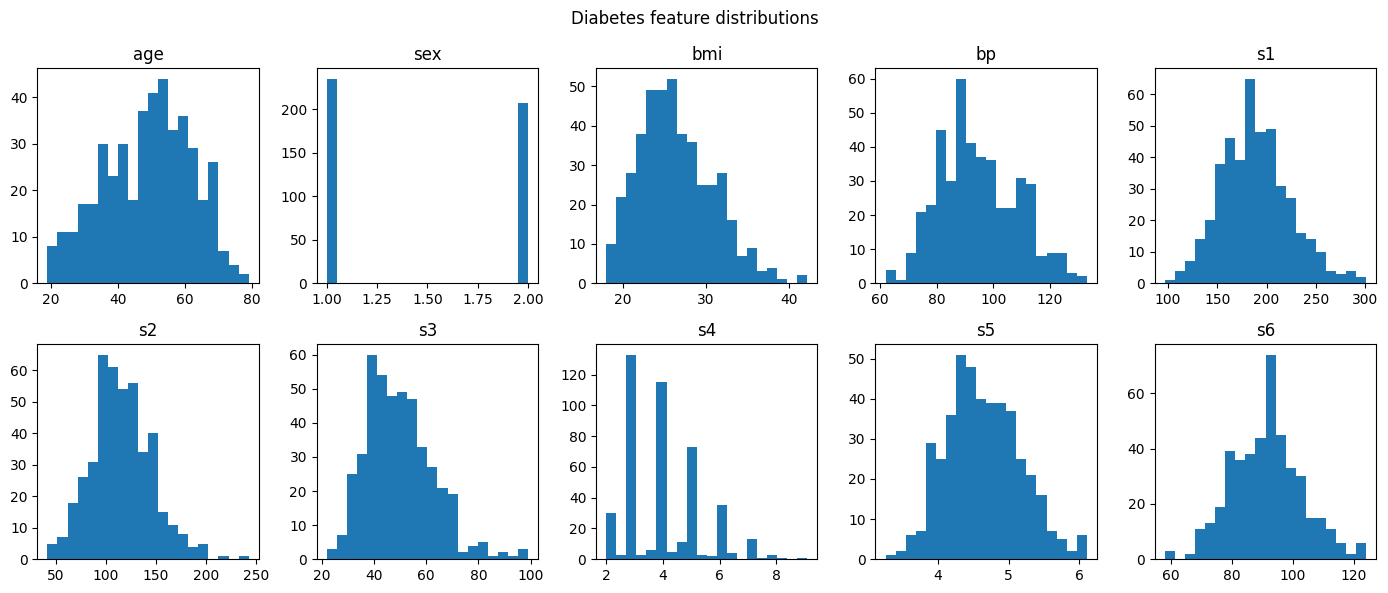

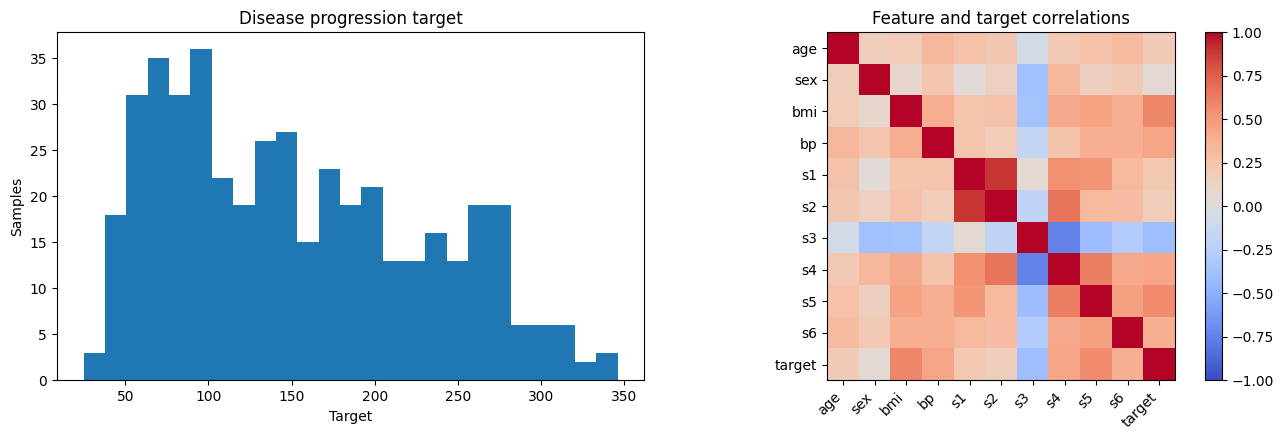

In [83]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for feature_index, axis in enumerate(axes.flat):
    axis.hist(x_all[:, feature_index], bins=20)
    axis.set_title(dataset.feature_names[feature_index])

plt.suptitle("Diabetes feature distributions")
plt.tight_layout()
plt.show()

correlations = np.corrcoef(
    np.column_stack([x_all, y_all]),
    rowvar=False,
)
labels = [*dataset.feature_names, "target"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(y_all, bins=25)
axes[0].set(
    title="Disease progression target",
    xlabel="Target",
    ylabel="Samples",
)

image = axes[1].imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(labels)), labels, rotation=45, ha="right")
axes[1].set_yticks(range(len(labels)), labels)
axes[1].set_title("Feature and target correlations")
fig.colorbar(image, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## Scale from training data only

Separate standardizers transform inputs and targets. Fitting them only on training rows prevents test information from leaking into model training.


In [84]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train_scaled = x_scaler.fit_transform(x_train).astype(np.float32)
x_test_scaled = x_scaler.transform(x_test).astype(np.float32)
y_train_scaled = y_scaler.fit_transform(y_train[:, None]).astype(np.float32)

assert np.allclose(x_train_scaled.mean(axis=0), 0.0, atol=1e-5)
assert np.allclose(y_train_scaled.mean(), 0.0, atol=1e-5)

## Historical baseline and matched MLPs

Ordinary linear regression provides a transparent historical reference for this dataset. The TinyMML and Keras models then use the same scikit-learn-inspired `10 → 100 → ReLU → 100 → ReLU → 1` architecture, He initialization, Adam at `1e-3`, light `1e-4` weight decay, batches of 200, and mean squared error.

The architecture follows scikit-learn's [published Diabetes MLP example](https://scikit-learn.org/1.4/auto_examples/miscellaneous/plot_partial_dependence_visualization_api.html). We run this fixed configuration without a hyperparameter search.


In [85]:
tiny_model = tm.Model([
    tm.Linear(100, init="he"),
    tm.ReLU(),
    tm.Linear(100, init="he"),
    tm.ReLU(),
    tm.Linear(1),
])
tiny_model.build(list(x_train_scaled.shape))
tiny_optimizer = tm.Adam(
    tiny_model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)
tiny_loss = tm.MSELoss()

keras_model = keras.Sequential([
    keras.layers.Input(shape=(10,)),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.ReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.ReLU(),
    keras.layers.Dense(1),
])
keras_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    ),
    loss="mse",
)

steps_per_epoch = int(
    np.ceil(len(x_train_scaled) / CONFIG["batch_size"])
)
model_info = [
    {
        "library": "TinyMML",
        "parameters": sum(
            parameter.size()
            for parameter in tiny_model.parameters()
        ),
        "steps/epoch": steps_per_epoch,
    },
    {
        "library": "Keras",
        "parameters": keras_model.count_params(),
        "steps/epoch": steps_per_epoch,
    },
]
display(Markdown(markdown_table(
    model_info,
    ["library", "parameters", "steps/epoch"],
)))

| library | parameters | steps/epoch |
| --- | --- | --- |
| TinyMML | 11301 | 12 |
| Keras | 11301 | 12 |

## Train and compare

Timings are CPU-only and hardware-dependent. Thread counts remain unset so OpenMP, BLAS, and TensorFlow can choose available parallelism. Keras uses optimized and often fused TensorFlow kernels; TinyMML keeps its teaching-oriented operations explicit, so runtime parity is not expected.


In [86]:
linear_model = LinearRegression()
linear_model.fit(x_train_scaled, y_train)
linear_predictions = linear_model.predict(x_test_scaled)

mean_predictions = np.full_like(y_test, y_train.mean())


In [87]:
started = perf_counter()
tiny_history = tiny_model.fit(
    x_train_scaled,
    y_train_scaled,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    optimizer=tiny_optimizer,
    loss_fn=tiny_loss,
    verbose=False,
)
tiny_train_seconds = perf_counter() - started

started = perf_counter()
keras_history = keras_model.fit(
    x_train_scaled,
    y_train_scaled,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    verbose=0,
)
keras_train_seconds = perf_counter() - started

In [88]:
tiny_scaled_predictions = tiny_model.predict(
    x_test_scaled,
    batch_size=CONFIG["batch_size"],
)
keras_scaled_predictions = keras_model.predict(
    x_test_scaled,
    batch_size=CONFIG["batch_size"],
    verbose=0,
)
tiny_predictions = y_scaler.inverse_transform(
    tiny_scaled_predictions,
).reshape(-1)
keras_predictions = y_scaler.inverse_transform(
    keras_scaled_predictions,
).reshape(-1)

tiny_latency, tiny_throughput = benchmark_inference(
    lambda: tiny_model.predict(
        x_test_scaled,
        batch_size=CONFIG["batch_size"],
    ),
    len(x_test_scaled),
    CONFIG["inference_repeats"],
)
keras_latency, keras_throughput = benchmark_inference(
    lambda: keras_model.predict(
        x_test_scaled,
        batch_size=CONFIG["batch_size"],
        verbose=0,
    ),
    len(x_test_scaled),
    CONFIG["inference_repeats"],
)

In [89]:
def quality_row(model_name, predictions):
    return {
        "model": model_name,
        "MAE": f"{mean_absolute_error(y_test, predictions):.2f}",
        "RMSE": f"{root_mean_squared_error(y_test, predictions):.2f}",
        "R2": f"{r2_score(y_test, predictions):.3f}",
    }


quality_results = [
    quality_row("Train mean", mean_predictions),
    quality_row("LinearRegression", linear_predictions),
    quality_row("TinyMML MLP", tiny_predictions),
    quality_row("Keras MLP", keras_predictions),
]
runtime_results = [
    {
        "library": "TinyMML",
        "training s": f"{tiny_train_seconds:.2f}",
        "inference ms": f"{tiny_latency:.3f}",
        "samples/s": f"{tiny_throughput:.1f}",
    },
    {
        "library": "Keras",
        "training s": f"{keras_train_seconds:.2f}",
        "inference ms": f"{keras_latency:.3f}",
        "samples/s": f"{keras_throughput:.1f}",
    },
]

display(Markdown(
    "### Predictive quality\n\n"
    + markdown_table(quality_results, list(quality_results[0]))
    + "\n\n### Matched MLP runtime\n\n"
    + markdown_table(runtime_results, list(runtime_results[0]))
))

### Predictive quality

| model | MAE | RMSE | R2 |
| --- | --- | --- | --- |
| Train mean | 64.01 | 73.22 | -0.012 |
| LinearRegression | 42.79 | 53.85 | 0.453 |
| TinyMML MLP | 52.05 | 67.99 | 0.127 |
| Keras MLP | 51.23 | 65.96 | 0.179 |

### Matched MLP runtime

| library | training s | inference ms | samples/s |
| --- | --- | --- | --- |
| TinyMML | 8.94 | 1.127 | 78998.5 |
| Keras | 7.04 | 19.360 | 4597.1 |

## Interpret the comparison

Compare each MLP's R² with the linear reference before judging its capacity. On a dataset this small, a larger neural network is not automatically a better estimator. If both matched MLPs trail the linear model, the result points to model and optimizer suitability rather than a TinyMML-only implementation problem. Scikit-learn's [MLPRegressor documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html) also notes that LBFGS can outperform Adam on small datasets; TinyMML currently provides SGD and Adam only.


## Diagnostics

Learning curves show MLP optimization. Predicted-versus-actual values and residuals compare both MLPs with the linear reference beyond aggregate metrics.


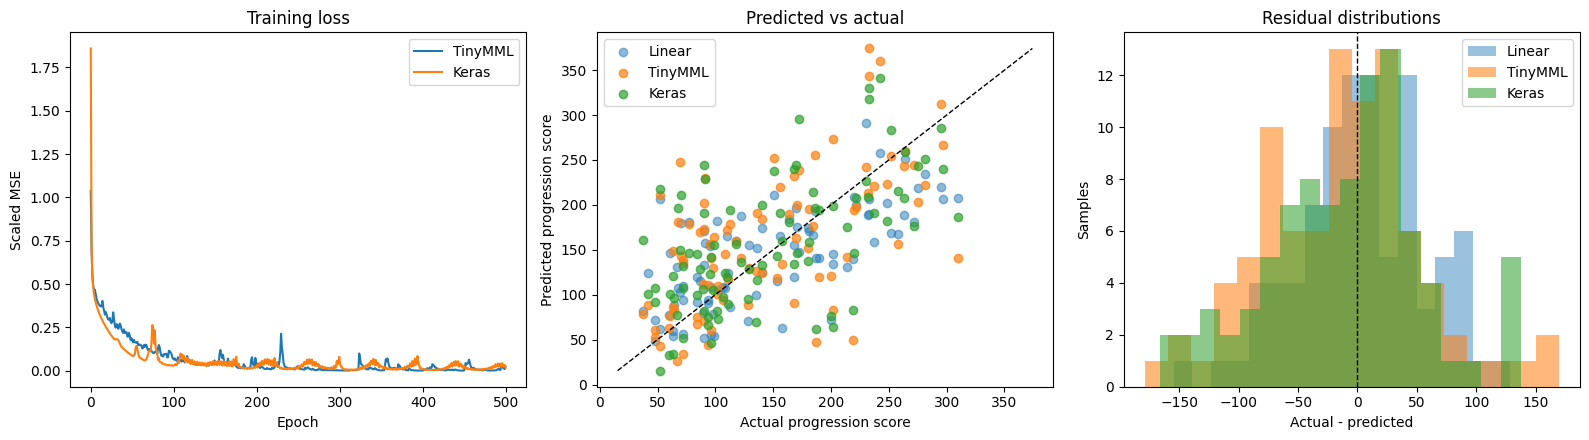

In [90]:
linear_residuals = y_test - linear_predictions
tiny_residuals = y_test - tiny_predictions
keras_residuals = y_test - keras_predictions

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(tiny_history["loss"], label="TinyMML")
axes[0].plot(keras_history.history["loss"], label="Keras")
axes[0].set(
    title="Training loss",
    xlabel="Epoch",
    ylabel="Scaled MSE",
)
axes[0].legend()

prediction_sets = [
    linear_predictions,
    tiny_predictions,
    keras_predictions,
]
limits = [
    min(y_test.min(), *(values.min() for values in prediction_sets)),
    max(y_test.max(), *(values.max() for values in prediction_sets)),
]
axes[1].scatter(
    y_test,
    linear_predictions,
    alpha=0.5,
    label="Linear",
)
axes[1].scatter(y_test, tiny_predictions, alpha=0.7, label="TinyMML")
axes[1].scatter(y_test, keras_predictions, alpha=0.7, label="Keras")
axes[1].plot(limits, limits, "k--", linewidth=1)
axes[1].set(
    title="Predicted vs actual",
    xlabel="Actual progression score",
    ylabel="Predicted progression score",
)
axes[1].legend()

axes[2].hist(linear_residuals, bins=18, alpha=0.45, label="Linear")
axes[2].hist(tiny_residuals, bins=18, alpha=0.55, label="TinyMML")
axes[2].hist(keras_residuals, bins=18, alpha=0.55, label="Keras")
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set(
    title="Residual distributions",
    xlabel="Actual - predicted",
    ylabel="Samples",
)
axes[2].legend()

plt.tight_layout()
plt.show()

In [91]:
combined_error = np.maximum.reduce([
    np.abs(linear_residuals),
    np.abs(tiny_residuals),
    np.abs(keras_residuals),
])
worst_indices = np.argsort(combined_error)[-8:][::-1]
worst_rows = [
    {
        "row": int(index),
        "actual": f"{y_test[index]:.1f}",
        "Linear": f"{linear_predictions[index]:.1f}",
        "TinyMML": f"{tiny_predictions[index]:.1f}",
        "Keras": f"{keras_predictions[index]:.1f}",
        "max abs error": f"{combined_error[index]:.1f}",
    }
    for index in worst_indices
]
display(Markdown(
    "### Largest test-set prediction errors\n\n"
    + markdown_table(worst_rows, list(worst_rows[0]))
))

tiny_mae = mean_absolute_error(y_test, tiny_predictions)
keras_mae = mean_absolute_error(y_test, keras_predictions)
tiny_r2 = r2_score(y_test, tiny_predictions)
keras_r2 = r2_score(y_test, keras_predictions)

### Largest test-set prediction errors

| row | actual | Linear | TinyMML | Keras | max abs error |
| --- | --- | --- | --- | --- | --- |
| 52 | 69.0 | 103.5 | 248.1 | 149.3 | 179.1 |
| 20 | 310.0 | 207.4 | 140.3 | 186.1 | 169.7 |
| 0 | 219.0 | 139.5 | 49.8 | 82.6 | 169.2 |
| 61 | 52.0 | 206.5 | 211.0 | 218.2 | 166.2 |
| 44 | 90.0 | 171.0 | 201.7 | 244.0 | 154.0 |
| 35 | 233.0 | 190.4 | 374.1 | 330.1 | 141.1 |
| 1 | 70.0 | 179.5 | 143.4 | 210.6 | 140.6 |
| 62 | 187.0 | 140.6 | 47.2 | 61.8 | 139.8 |